### Setup Environment

In [23]:
# Import libraries
import os
import opensmile
import pandas as pd
import librosa
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import warnings
warnings.filterwarnings("ignore")

### Define Directories and Feature Sets

In [4]:
# Define data directories
data_dir = "data"  # Main data folder
healthy_dir = os.path.join(data_dir, "HC_AH")  # Healthy patients
parkinson_dir = os.path.join(data_dir, "PD_AH")  # Parkinson's patients

# Define OpenSMILE feature sets and levels
feature_sets = [
    'ComParE_2016', 'eGeMAPSv01a', 'eGeMAPSv01b', 'eGeMAPSv02',
    'emobase', 'GeMAPSv01a', 'GeMAPSv01b'
]
feature_levels = ['Functionals', 'LowLevelDescriptors']

# Define required features from the paper
required_features = [   
    'jitterLocal_sma3nz_amean',
    'jitterLocal_sma3nz_stddevNorm',
    'jitterLocal_sma3nz_max',
    'jitterLocal_sma3nz_min',
    'jitterDDP_sma3nz_amean',
    'jitterDDP_sma_de_stddev',
    'jitterLocal_sma_de_upleveltime25',
    'shimmerLocal_sma3nz_amean',
    'shimmerLocal_sma3nz_stddevNorm',
    'shimmerLocal_sma3nz_max',
    'shimmerLocal_sma3nz_min',
    'shimmerAPQ3_sma3nz',
    'shimmerAPQ5_sma3nz',
    'shimmerAPQ11_sma3nz',
    'shimmerLocal_sma_de_upleveltime50',
    'shimmerLocaldB_sma3nz_stddevNorm',
    'HNRdBACF_sma3nz',
    'HNRdBACF_sma3nz_amean',
    'HNRdBACF_sma3nz_stddevNorm',
    'logHNR_sma3nz',
    'logHNR_sma_lpgain',
    'logHNR_sma_de_flatness',
    'F0semitoneFrom27.5Hz_sma3nz_amean',
    'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
    'F0semitoneFrom27.5Hz_sma3nz_max',
    'F0semitoneFrom27.5Hz_sma3nz_min',
    'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
    'pcm_RMSenergy_sma3_amean',
    'pcm_RMSenergy_sma3_stddevNorm',
    'pcm_fftMag_fband250-650_sma_peakRangeRel',
    'pcm_fftMag_fband250-650_sma_stddev',
    'pcm_fftMag_fband250-650_sma_quartile1',
    'pcm_fftMag_fband250-650_sma3_amean',
    'pcm_fftMag_fband250-650_sma3_stddevNorm',
    'voiceBreaksPerSecond',
    'voicingFinalUnclipped_sma3nz_mean',
    'voicingFinalUnclipped_sma3nz_stddev',
    'voicingFinalUnclipped_sma3nz_stddevNorm',
    'voicingFinalUnclipped_sma_rqmean',
]


### Extract Features for All Feature Sets and Levels

In [6]:
# Initialize list to store feature data
feature_data = []

# Function to extract features for a single audio file
def extract_features(file_path, label, file_id):
    # Load audio signal
    signal, sampling_rate = librosa.load(file_path, sr=None, mono=True)
    
    # Initialize a dictionary to store the combined features
    combined_features = {'label': label, 'file_id': file_id}
    
    # Loop through all feature sets and levels
    for feature_set in feature_sets:
        for level in feature_levels:
            try:
                # Initialize OpenSMILE for the current feature set and level
                smile = opensmile.Smile(
                    feature_set=getattr(opensmile.FeatureSet, feature_set, None),
                    feature_level=getattr(opensmile.FeatureLevel, level, None)
                )
                
                # Process the audio signal
                features = smile.process_signal(signal, sampling_rate)
                
                # Filter and add only the required features
                for feature in required_features:
                    if feature in features.columns:
                         combined_features[feature] = features[feature].iloc[0]
            except Exception as e:
                # Print a simplified error message and skip invalid combinations
                print(f"Skipping {feature_set} at {level}: {e}")
    
    # Return the combined features
    return combined_features



In [7]:
# Process all files in both healthy and Parkinson's folders
file_id = 1  # File numbering starts from 1
for folder, label in [(healthy_dir, 0), (parkinson_dir, 1)]:
    for file in os.listdir(folder):
        if file.endswith(".wav"):  # Process only .wav files
            file_path = os.path.join(folder, file)
            try:
                # Extract features and append to the feature data list
                features = extract_features(file_path, label, f"File_{file_id}")
                feature_data.append(features)
                file_id += 1
            except Exception as e:
                print(f"Error processing {file}: {e}")

# Convert the feature data into a DataFrame
feature_df = pd.DataFrame(feature_data)


In [8]:
feature_df

,label,file_id,jitterDDP_sma_de_stddev,jitterLocal_sma_de_upleveltime25,shimmerLocal_sma_de_upleveltime50,logHNR_sma_lpgain,logHNR_sma_de_flatness,pcm_fftMag_fband250-650_sma_peakRangeRel,pcm_fftMag_fband250-650_sma_stddev,pcm_fftMag_fband250-650_sma_quartile1,voicingFinalUnclipped_sma_rqmean,jitterLocal_sma3nz_amean,jitterLocal_sma3nz_stddevNorm,shimmerLocaldB_sma3nz_stddevNorm,HNRdBACF_sma3nz_amean,HNRdBACF_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,HNRdBACF_sma3nz
0,0,File_1,0.000119,0.997214,0.994429,36.760506,0.013368,0.730759,0.270677,0.905557,0.810072,0.004371,0.529410,0.603546,8.307067,0.079763,27.182825,0.015623,2.821403,0.000000
1,0,File_2,0.000016,0.995238,0.985782,60.278572,0.020692,0.719499,0.488884,0.370838,0.768965,0.005793,0.610212,0.523561,6.499732,0.126182,24.147161,0.009580,3.413859,0.000000
2,0,File_3,0.000100,0.996324,0.992647,45.480995,0.020426,0.534799,0.544552,1.494704,0.840410,0.004847,1.185104,0.940736,13.018598,0.110631,37.131664,0.003260,2.395560,0.000000
3,0,File_4,0.000065,0.992701,0.989091,47.538078,0.010462,0.753957,0.220333,0.589418,0.762617,0.004663,1.517298,0.553196,6.399995,0.159030,22.878942,0.008030,2.658834,0.000000
4,0,File_5,0.000009,0.995110,0.975610,2.086884,0.130255,0.878799,0.099037,0.082972,0.771283,0.004141,0.571693,0.556314,6.188959,0.130538,24.284147,0.008939,4.338348,3.269764
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,1,File_77,0.000005,0.984925,0.002500,1.425528,0.152347,0.000000,0.269837,0.003459,0.820705,0.009661,1.159498,0.595095,7.995584,0.384833,34.434311,0.011962,2.563015,10.037217
77,1,File_78,0.000004,0.998584,0.995751,2.347084,0.208567,0.679754,0.336066,0.004173,0.827856,0.002914,0.493569,0.879429,9.632190,0.152075,31.530104,0.005430,3.087002,0.727436
78,1,File_79,0.000144,0.992857,0.971831,5.298474,0.470083,0.690764,0.127574,0.187220,0.874207,0.003760,1.575780,1.268702,8.217691,0.452455,38.839710,0.007152,6.636286,1.457196
79,1,File_80,0.000018,0.995690,0.051502,54.447258,0.011934,0.880627,0.864497,0.619205,0.780215,0.004346,0.694499,0.736781,7.766114,0.128558,26.272806,0.007529,2.665959,0.000000


### Save Features to Excel

In [10]:
# Save the extracted features to an Excel file
output_file = "parkinson_features_all_sets.xlsx"
feature_df.to_excel(output_file, index=False)
print(f"Feature data saved to {output_file}")


Feature data saved to parkinson_features_all_sets.xlsx


### Data Preprocessing

In [12]:
# Find available features in the DataFrame
available_features = [feature for feature in required_features if feature in feature_df.columns]

# Check if any required features are missing
missing_features = [feature for feature in required_features if feature not in feature_df.columns]
print(f"Missing features: {missing_features}")

# Use only available features for X
X = feature_df[available_features]
y = feature_df['label']

Missing features: ['jitterLocal_sma3nz_max', 'jitterLocal_sma3nz_min', 'jitterDDP_sma3nz_amean', 'shimmerLocal_sma3nz_amean', 'shimmerLocal_sma3nz_stddevNorm', 'shimmerLocal_sma3nz_max', 'shimmerLocal_sma3nz_min', 'shimmerAPQ3_sma3nz', 'shimmerAPQ5_sma3nz', 'shimmerAPQ11_sma3nz', 'logHNR_sma3nz', 'F0semitoneFrom27.5Hz_sma3nz_max', 'F0semitoneFrom27.5Hz_sma3nz_min', 'pcm_RMSenergy_sma3_amean', 'pcm_RMSenergy_sma3_stddevNorm', 'pcm_fftMag_fband250-650_sma3_amean', 'pcm_fftMag_fband250-650_sma3_stddevNorm', 'voiceBreaksPerSecond', 'voicingFinalUnclipped_sma3nz_mean', 'voicingFinalUnclipped_sma3nz_stddev', 'voicingFinalUnclipped_sma3nz_stddevNorm']


In [13]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top features
selector = SelectKBest(score_func=f_classif, k=8)
X_selected = selector.fit_transform(X_scaled, y)

# Get selected feature indices
selected_features = selector.get_support(indices=True)
print(f"Selected features: {np.array(available_features)[selected_features]}")


Selected features: ['HNRdBACF_sma3nz' 'HNRdBACF_sma3nz_amean' 'logHNR_sma_de_flatness'
 'F0semitoneFrom27.5Hz_sma3nz_amean'
 'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope'
 'pcm_fftMag_fband250-650_sma_peakRangeRel'
 'pcm_fftMag_fband250-650_sma_stddev' 'voicingFinalUnclipped_sma_rqmean']


In [15]:
from imblearn.over_sampling import SMOTE

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)

# Check class distribution after resampling
print(f"Class distribution after SMOTE: {np.bincount(y_resampled)}")


Class distribution after SMOTE: [41 41]


In [16]:
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)


## Train Baseline Models

### SVM Model

In [25]:
from sklearn.svm import SVC

# Train an SVM model
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

# Evaluate the SVM model
y_pred_svm = svm_model.predict(X_test)
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.2f}")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.60
[[12  3]
 [ 7  3]]
              precision    recall  f1-score   support

           0       0.63      0.80      0.71        15
           1       0.50      0.30      0.38        10

    accuracy                           0.60        25
   macro avg       0.57      0.55      0.54        25
weighted avg       0.58      0.60      0.57        25



### Random Forest Model

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate the Random Forest model
y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.76
[[10  5]
 [ 1  9]]
              precision    recall  f1-score   support

           0       0.91      0.67      0.77        15
           1       0.64      0.90      0.75        10

    accuracy                           0.76        25
   macro avg       0.78      0.78      0.76        25
weighted avg       0.80      0.76      0.76        25



### MLP Model

In [29]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Define the baseline MLP model
mlp_model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
mlp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
mlp_history = mlp_model.fit(X_train, y_train, epochs=40, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Evaluate the model
mlp_loss, mlp_accuracy = mlp_model.evaluate(X_test, y_test)
print(f"Baseline MLP Accuracy: {mlp_accuracy:.2f}")


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.6373 - loss: 0.6826 - val_accuracy: 0.6800 - val_loss: 0.6751
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6409 - loss: 0.6585 - val_accuracy: 0.7200 - val_loss: 0.6703
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6568 - loss: 0.6294 - val_accuracy: 0.7200 - val_loss: 0.6656
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6479 - loss: 0.6087 - val_accuracy: 0.6800 - val_loss: 0.6615
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6750 - loss: 0.6022 - val_accuracy: 0.6800 - val_loss: 0.6551
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6771 - loss: 0.5813 - val_accuracy: 0.6800 - val_loss: 0.6504
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6570 - loss: 0.5966 - val_accuracy: 0.6800 - val_loss: 0.6447
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6570 - loss: 0.5776 - val_accuracy: 0.6800 - val_loss: 0.6393


### CNN Model

In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# Reshape data for CNN (CNN expects a 3D input: samples, timesteps, features)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Define a simple CNN model
cnn_model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

# Compile the CNN model
cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the CNN model
cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs=40, batch_size=16, validation_data=(X_test_cnn, y_test))

# Evaluate the CNN model
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test)
print(f"Baseline CNN Accuracy: {cnn_accuracy:.2f}")


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.4889 - loss: 0.7949 - val_accuracy: 0.7600 - val_loss: 0.6704
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6284 - loss: 0.6930 - val_accuracy: 0.6800 - val_loss: 0.6696
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6576 - loss: 0.6551 - val_accuracy: 0.6000 - val_loss: 0.6717
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7390 - loss: 0.6296 - val_accuracy: 0.6000 - val_loss: 0.6698
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6792 - loss: 0.6253 - val_accuracy: 0.6000 - val_loss: 0.6663
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6672 - loss: 0.5954 - val_accuracy: 0.6000 - val_loss: 0.6625
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6659 - loss: 0.6181 - val_accuracy: 0.6000 - val_loss: 0.6609
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6883 - loss: 0.6064 - val_accuracy: 0.6000 - val_loss: 0.6586


## Hyperparameter Tuning
### Grid Search for Random Forest

In [33]:
from sklearn.model_selection import GridSearchCV

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# Perform Grid Search
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Best Parameters
print(f"Best Random Forest Parameters: {grid_search.best_params_}")

# Evaluate the best model
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
print(f"Random Forest Accuracy (Best Parameters): {accuracy_score(y_test, y_pred_best_rf):.2f}")


Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Random Forest Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Random Forest Accuracy (Best Parameters): 0.76


### Enhanced MLP with Improvements

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import keras_tuner as kt

# Define an enhanced MLP model
def build_model(hp):
    model = Sequential()
    model.add(Dense(hp.Int('units_input', min_value=32, max_value=128, step=32), activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(hp.Float('dropout_input', min_value=0.2, max_value=0.5, step=0.1)))
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(hp.Int(f'units_{i}', min_value=32, max_value=128, step=32), activation='relu'))
        model.add(Dropout(hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize Keras Tuner
tuner = kt.Hyperband(build_model, objective='val_accuracy', max_epochs=40, factor=3, directory='my_dir', project_name='mlp_tuning')

# Perform tuning
tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test), verbose=1)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Best Hyperparameters: {best_hps.values}")

# Train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(X_train, y_train, epochs=40, batch_size=16, validation_data=(X_test, y_test))

# Evaluate the best model
loss, accuracy = best_model.evaluate(X_test, y_test)
print(f"Enhanced MLP Accuracy: {accuracy:.2f}")


Reloading Tuner from my_dir\mlp_tuning\tuner0.json
Best Hyperparameters: {'units_input': 96, 'dropout_input': 0.30000000000000004, 'num_layers': 1, 'units_0': 96, 'dropout_0': 0.4, 'units_1': 32, 'dropout_1': 0.30000000000000004, 'units_2': 32, 'dropout_2': 0.4, 'tuner/epochs': 17, 'tuner/initial_epoch': 0, 'tuner/bracket': 1, 'tuner/round': 0}
Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - accuracy: 0.3643 - loss: 0.7957 - val_accuracy: 0.4000 - val_loss: 0.7044
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5389 - loss: 0.6480 - val_accuracy: 0.4800 - val_loss: 0.6915
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5225 - loss: 0.6837 - val_accuracy: 0.6400 - val_loss: 0.6768
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6547 - loss: 0.6177 - val_accuracy: 0.6000 - val_loss: 0.6670
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6274 - loss: 0.6366 - val_accuracy: 0.6000 - val_loss: 0.6552
Epoch 6/40
4/4 ━━━━━━━━━━━━━

### Ensemble Learning

In [37]:
from sklearn.ensemble import VotingClassifier
from scikeras.wrappers import KerasClassifier

# Wrap MLP model
def create_model():
    model = Sequential([
        Dense(128, activation='relu', input_dim=X_train.shape[1]),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mlp_sklearn = KerasClassifier(build_fn=create_model, epochs=50, batch_size=16, verbose=0)

# Ensemble Model
ensemble = VotingClassifier(estimators=[('svm', svm_model), ('rf', rf_model), ('mlp', mlp_sklearn)], voting='soft')
ensemble.fit(X_train, y_train)

# Evaluate Ensemble
y_pred_ensemble = ensemble.predict(X_test)
print(f"Ensemble Accuracy: {accuracy_score(y_test, y_pred_ensemble):.2f}")


Ensemble Accuracy: 0.76


### Enhanced CNN

In [39]:
def build_cnn_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Int('filters_1', min_value=16, max_value=64, step=16),
                     kernel_size=hp.Choice('kernel_size', values=[3, 5]),
                     activation='relu', input_shape=(X_train.shape[1], 1)))
    model.add(MaxPooling1D(pool_size=hp.Choice('pool_size', values=[2, 3])))
    model.add(Flatten())
    model.add(Dense(hp.Int('dense_units', min_value=32, max_value=128, step=32), activation='relu'))
    model.add(Dropout(hp.Float('dropout', min_value=0.2, max_value=0.5, step=0.1)))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Tuning with Keras Tuner
cnn_tuner = kt.Hyperband(build_cnn_model, objective='val_accuracy', max_epochs=40, factor=3, directory='cnn_tuning', project_name='cnn')

cnn_tuner.search(X_train_cnn, y_train, epochs=50, validation_data=(X_test_cnn, y_test), verbose=1)

# Train the best CNN model
best_cnn_hps = cnn_tuner.get_best_hyperparameters(num_trials=1)[0]
best_cnn_model = cnn_tuner.hypermodel.build(best_cnn_hps)
best_cnn_model.fit(X_train_cnn, y_train, epochs=40, batch_size=16, validation_data=(X_test_cnn, y_test))

# Evaluate the best CNN model
cnn_loss, cnn_accuracy = best_cnn_model.evaluate(X_test_cnn, y_test)
print(f"Enhanced CNN Accuracy: {cnn_accuracy:.2f}")


Reloading Tuner from cnn_tuning\cnn\tuner0.json
Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.5727 - loss: 0.6783 - val_accuracy: 0.6800 - val_loss: 0.6705
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5964 - loss: 0.6596 - val_accuracy: 0.6800 - val_loss: 0.6667
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6687 - loss: 0.6485 - val_accuracy: 0.6800 - val_loss: 0.6645
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5537 - loss: 0.6478 - val_accuracy: 0.6800 - val_loss: 0.6668
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5539 - loss: 0.6232 - val_accuracy: 0.6800 - val_loss: 0.6612
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5922 - loss: 0.6262 - val_accuracy: 0.6800 - val_loss: 0.6556
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6638 - loss: 0.6133 - val_accuracy: 0.6800 - val_loss: 0.6504
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6526 - loss: 0

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
                    Model  Accuracy  Precision  Recall  F1-Score
0                     SVM      0.60   0.500000     0.3  0.375000
1           Random Forest      0.76   0.642857     0.9  0.750000
2                     MLP      0.64   0.545455     0.6  0.571429
3                     CNN      0.76   0.700000     0.7  0.700000
4  Hyper Parameter Tuning      0.76   0.642857     0.9  0.750000
5            Enhanced MLP      0.84   0.800000     0.8  0.800000
6            Enhanced CNN      0.72   0.636364     0.7  0.666667
7                Ensemble      0.76   0.666667     0.8  0.727273


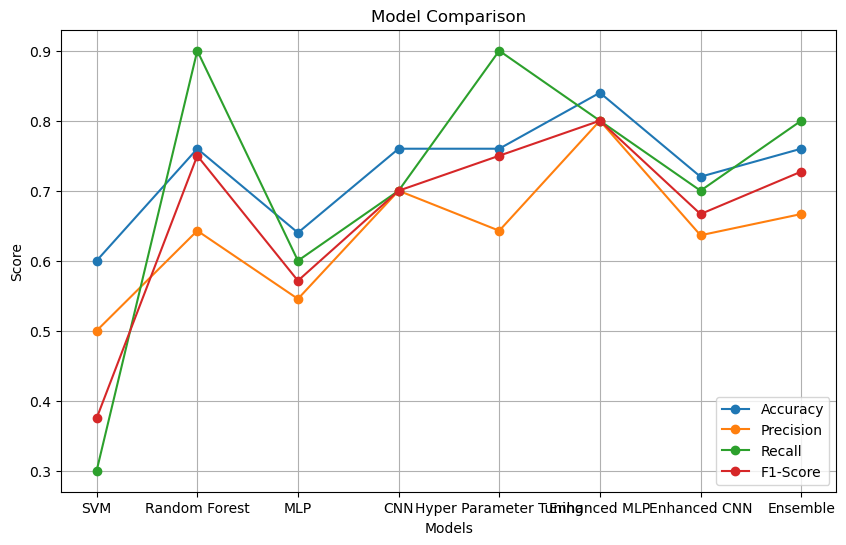

In [40]:
results = []

# Define a function to evaluate models
def evaluate_model(name, model, X_test, y_test, is_dl=False):
    if is_dl:
        # For deep learning models, use model.evaluate()
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
        y_pred = (model.predict(X_test) > 0.5).astype(int)
    else:
        # For sklearn models
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Append results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Evaluate basic models
evaluate_model("SVM", svm_model, X_test, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("MLP", mlp_model, X_test, y_test, is_dl=True)
evaluate_model("CNN", cnn_model, X_test_cnn, y_test, is_dl=True)

# Evaluate enhanced models
evaluate_model("Hyper Parameter Tuning", best_rf_model, X_test, y_test)
evaluate_model("Enhanced MLP", best_model, X_test, y_test, is_dl=True)
evaluate_model("Enhanced CNN", best_cnn_model, X_test_cnn, y_test, is_dl=True)
evaluate_model("Ensemble", ensemble, X_test, y_test)

# Display results
results_df = pd.DataFrame(results)
print(results_df)

# Optional: Plot the results for better visualization
import matplotlib.pyplot as plt

# Plot comparison
plt.figure(figsize=(10, 6))
for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    plt.plot(results_df["Model"], results_df[metric], marker='o', label=metric)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xlabel("Models")
plt.legend()
plt.grid()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
                    Model  Accuracy  Precision  Recall  F1-Score
0                     SVM      0.60   0.500000     0.3  0.375000
1           Random Forest      0.76   0.642857     0.9  0.750000
2                     MLP      0.64   0.545455     0.6  0.571429
3                     CNN      0.76   0.700000     0.7  0.700000
4  Hyper Parameter Tuning      0.76   0.642857     0.9  0.750000
5            Enhanced MLP      0.84   0.800000     0.8  0.800000
6            Enhanced CNN      0.72   0.636364     0.7  0.666667
7                Ensemble      0.76   0.666667     0.8  0.727273


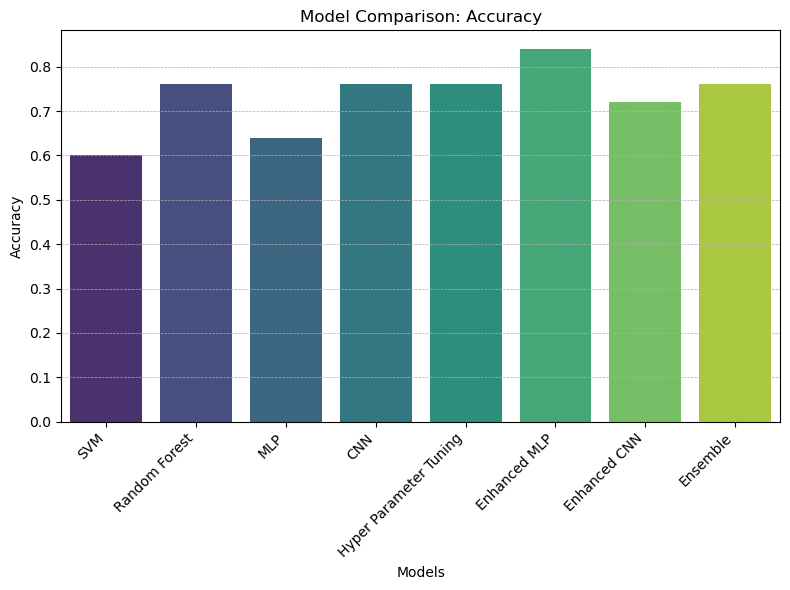

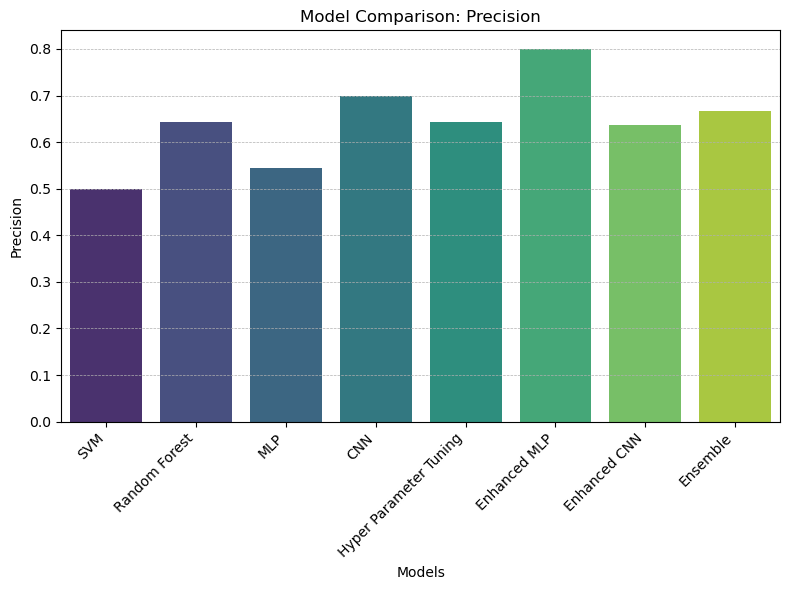

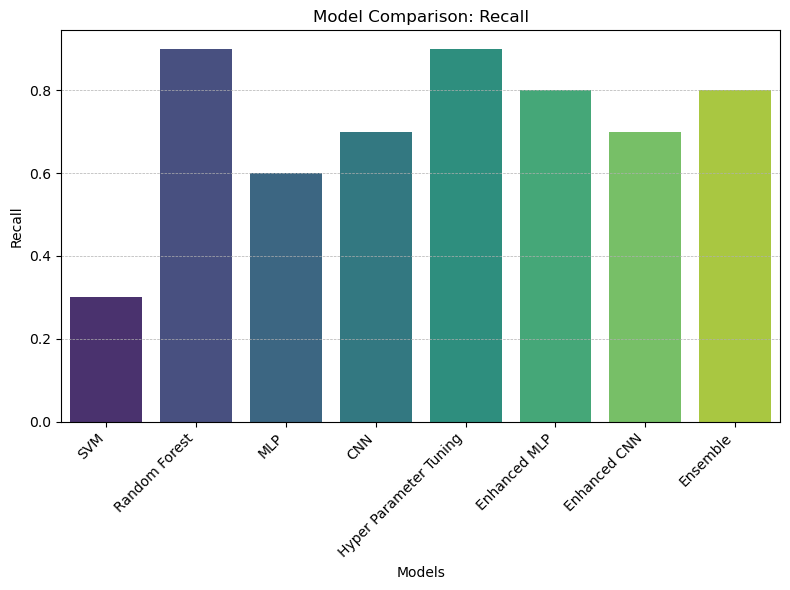

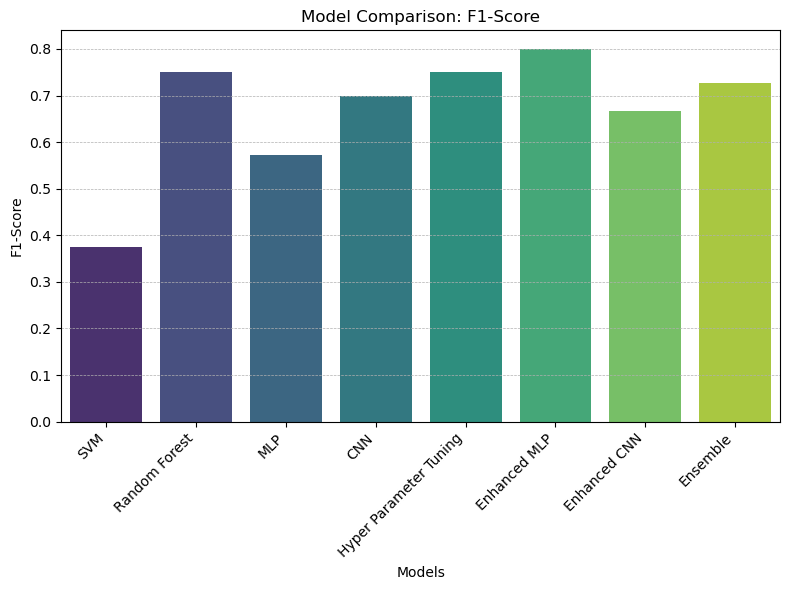

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Placeholder for results
results = []

# Define a function to evaluate models
def evaluate_model(name, model, X_test, y_test, is_dl=False):
    if is_dl:
        # For deep learning models, use model.evaluate()
        loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
        y_pred = (model.predict(X_test) > 0.5).astype(int)
    else:
        # For sklearn models
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
    
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Append results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Evaluate models
evaluate_model("SVM", svm_model, X_test, y_test)
evaluate_model("Random Forest", rf_model, X_test, y_test)
evaluate_model("MLP", mlp_model, X_test, y_test, is_dl=True)
evaluate_model("CNN", cnn_model, X_test_cnn, y_test, is_dl=True)
evaluate_model("Hyper Parameter Tuning", best_rf_model, X_test, y_test)
evaluate_model("Enhanced MLP", best_model, X_test, y_test, is_dl=True)
evaluate_model("Enhanced CNN", best_cnn_model, X_test_cnn, y_test, is_dl=True)
evaluate_model("Ensemble", ensemble, X_test, y_test)

# Create a DataFrame for results
results_df = pd.DataFrame(results)

# Display the results in tabular form
print(results_df)

# Plot separate vertical bar graphs for each metric
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

for metric in metrics:
    plt.figure(figsize=(8, 6))
    sns.barplot(x="Model", y=metric, data=results_df, palette="viridis")
    plt.title(f"Model Comparison: {metric}")
    plt.ylabel(metric)
    plt.xlabel("Models")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()
